# 질문별 그래프 모음 — 먼저 그림 살펴보기

공식 요구사항의 다섯 질문을 위한 **9개 이미지**입니다. 각 그림에 Batch 1·2·3을 함께 표시합니다. 관찰·해석·Feature 선정·모델 판단은 여기에 작성하지 않습니다.

프로젝트 `.venv` 커널에서 위에서부터 전체 실행하면 이미지를 다시 생성하고 표시합니다. PNG는 `outputs/figures/question_gallery/`에 저장하며 이후 대화에서 파일명으로 참조할 수 있습니다.

공통 표시 기준: 원본 셀과 타깃을 유지합니다. QD/IR의 비유한값·0 이하 값만 분석용 열에서 NaN으로 표시합니다. 높은 양의 QD는 자동 제거하지 않습니다. 수명 그룹은 <500 / 500–1000 / >1000이며 수명 누락은 별도로 표시합니다.

In [1]:
from pathlib import Path
import sys, importlib
import matplotlib.pyplot as plt
from IPython.display import display

cwd = Path.cwd().resolve()
PROJECT_ROOT = next((p for p in [cwd, *cwd.parents]
                     if (p / "src/question_gallery.py").is_file()
                     and (p / "requirements.txt").is_file()), None)
if PROJECT_ROOT is None:
    raise RuntimeError("프로젝트 디렉토리에서 실행하세요.")
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
from src import question_gallery
importlib.reload(question_gallery)
OUTPUT_DIR = PROJECT_ROOT / "outputs/figures/question_gallery"
batches, features, curves, audit = question_gallery.build_gallery_data(PROJECT_ROOT / "data/raw")
inputs = {"batches": batches, "features": features, "curves": curves, "audit": audit}
question_gallery.save_audit(inputs, OUTPUT_DIR)
print("Python:", sys.executable)
print("Images:", OUTPUT_DIR)
print("Cycle 10/100 checks:", len(audit), "; QD alignment passed:", audit.QD_alignment_passed.sum())

Matplotlib is building the font cache; this may take a moment.


Python: /Users/soobin/myfolder/workspace/mini-project-data-analysis/.venv/bin/python
Images: /Users/soobin/myfolder/workspace/mini-project-data-analysis/outputs/figures/question_gallery
Cycle 10/100 checks: 278 ; QD alignment passed: 278


## 로딩 / 계산 조건

초기 Feature 구간은 실제 summary cycle 10–100입니다. ΔQ(V)는 cycle 100 − cycle 10입니다. 상세 데이터의 위치는 summary cycle 배열에서 찾고, 상세 Qd 최댓값이 해당 summary QD와 일치하는지 확인한 뒤 사용합니다. 전압 격자·곡선 길이·유한값도 확인합니다. 위치 확인 결과는 `cycle_alignment_audit.csv`에 저장합니다.

전류 `I`와 `chargetime`은 원본 단위로 표시합니다. 원본 전류를 A로 환산하거나 충전 시간 지표를 0–100% 완충 시간으로 해석하지 않습니다. Pearson/Spearman은 관계를 보여주는 지표이며 원인을 증명하지 않습니다. 사용 셀 수는 그림 안에 표시합니다.

이 노트북은 원본을 합치거나 타깃을 재산출하지 않습니다. 반복 측정 연장 여부와 타깃 정의는 별도 검토 사항입니다.

## 01. Q1 — Cycle-life distribution and box plots

전체 수명 분포와 개별 셀을 봅니다. 상단 Histogram은 150–2300 범위이며, 하단은 Box plot과 개별 점입니다. IQR 규칙 밖의 셀에만 ID를 붙입니다. 측정 오류 판정이 아닙니다.

저장 파일: `01_q1_cycle_life_distribution.png`

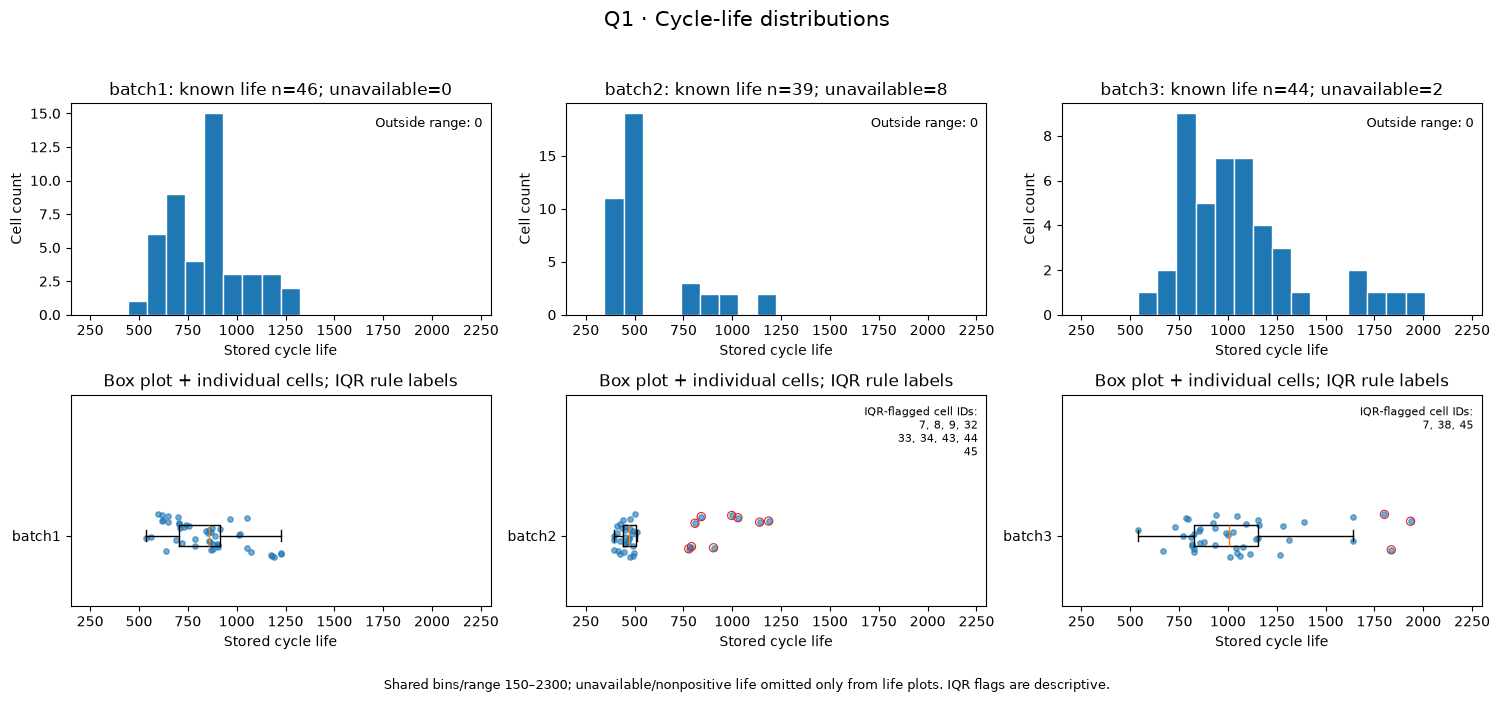

In [2]:
fig = question_gallery.save_gallery_figure(question_gallery.FIGURE_SPECS[0], inputs, OUTPUT_DIR)
plt.show()
plt.close(fig)

## 02. Q1 — Lifetime-group proportions

수명 그룹별 비율과 개수를 봅니다. 분모는 원본의 전체 셀 항목 수이며, 수명 누락 그룹도 표시합니다.

저장 파일: `02_q1_life_group_ratios.png`

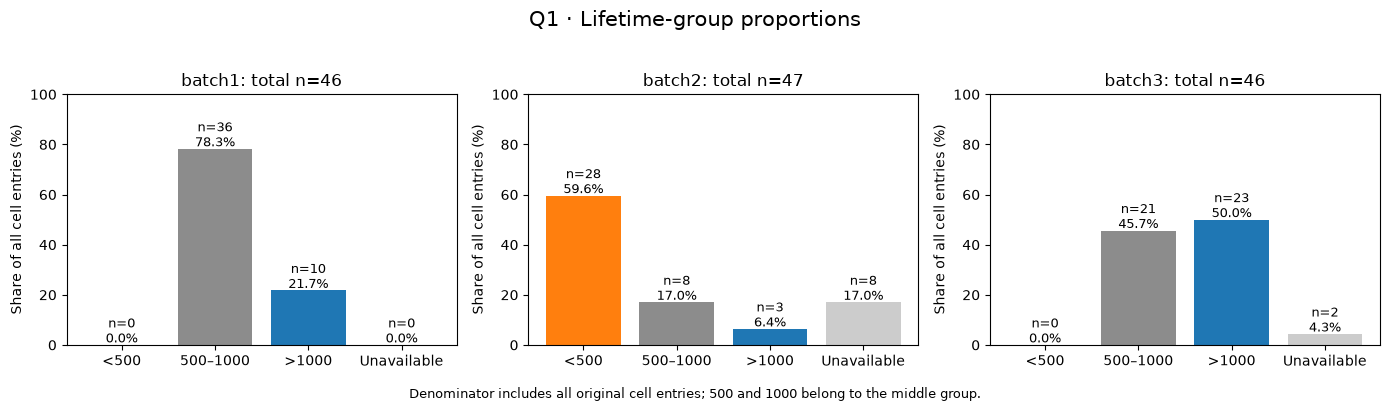

In [3]:
fig = question_gallery.save_gallery_figure(question_gallery.FIGURE_SPECS[1], inputs, OUTPUT_DIR)
plt.show()
plt.close(fig)

## 03. Q2 — Full and early discharge-capacity curves

전체 구간과 초기 100회차를 봅니다. 마지막 행은 0.8–1.15 Ah 범위 확대이며, 범위 밖 점 수를 명시합니다. Knee point나 열화 원인을 자동 판정하지 않습니다.

저장 파일: `03_q2_degradation_curves.png`

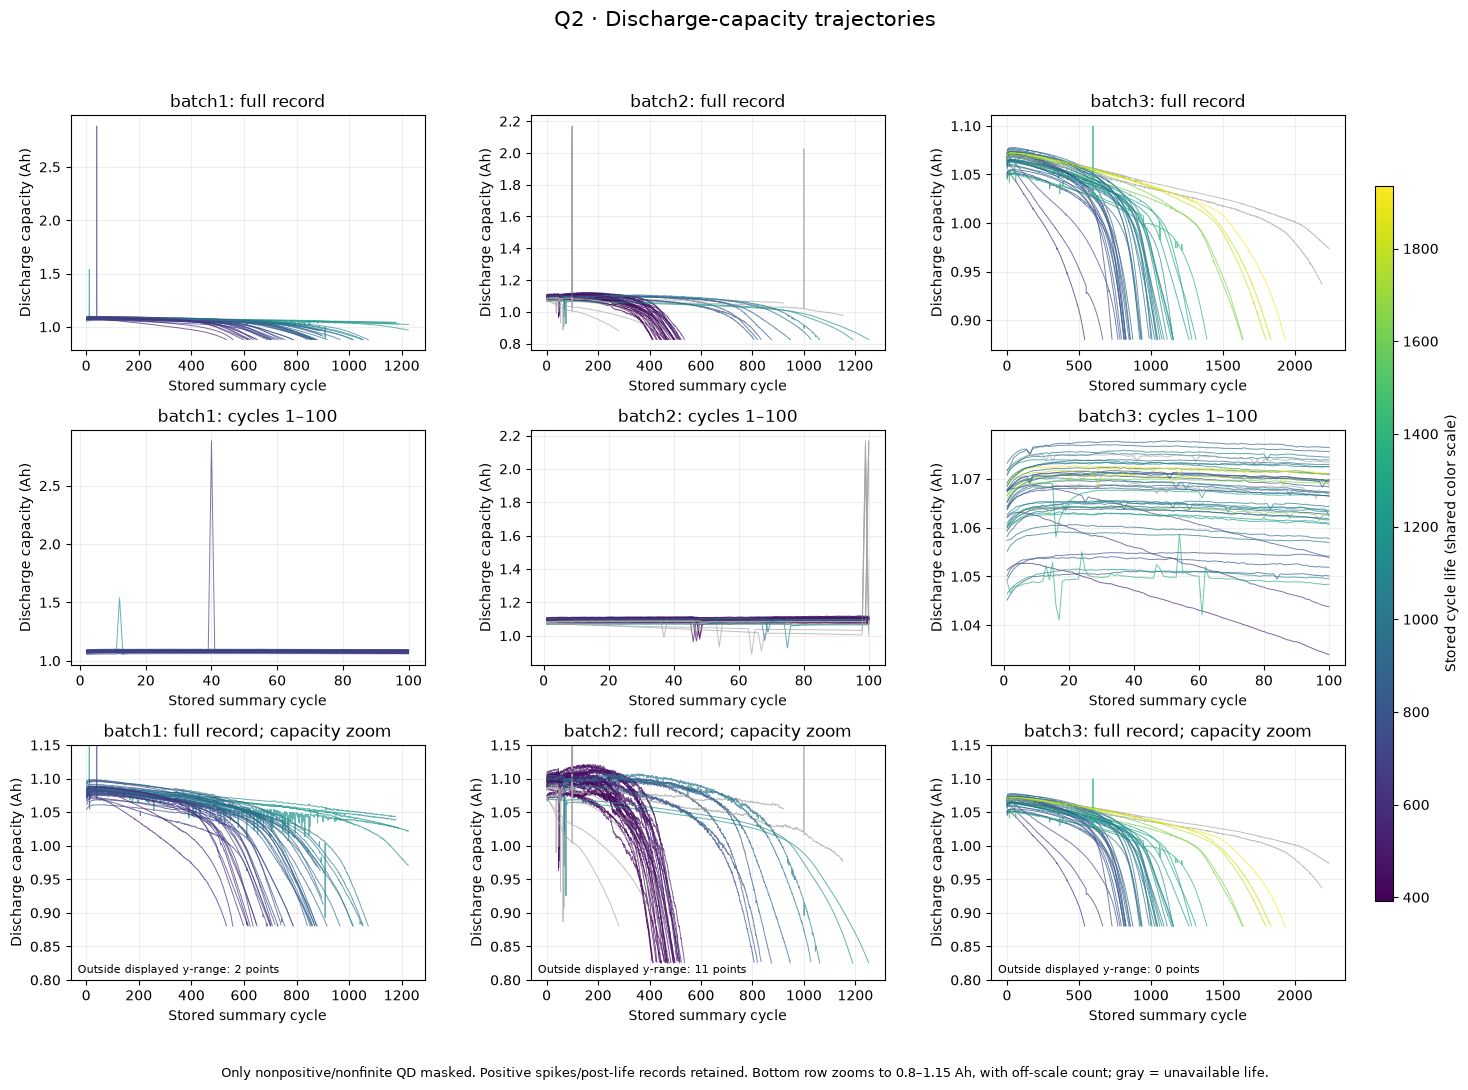

In [4]:
fig = question_gallery.save_gallery_figure(question_gallery.FIGURE_SPECS[2], inputs, OUTPUT_DIR)
plt.show()
plt.close(fig)

## 04. Q3 — Delta-Q curves by lifetime group

각 셀의 ΔQ(V) 곡선과 수명 그룹별 중앙값을 봅니다. 얇은 선은 개별 셀, 굵은 선은 그룹 중앙값입니다. 셀이 없는 그룹은 n=0으로 표시합니다.

저장 파일: `04_q3_delta_q_curves.png`

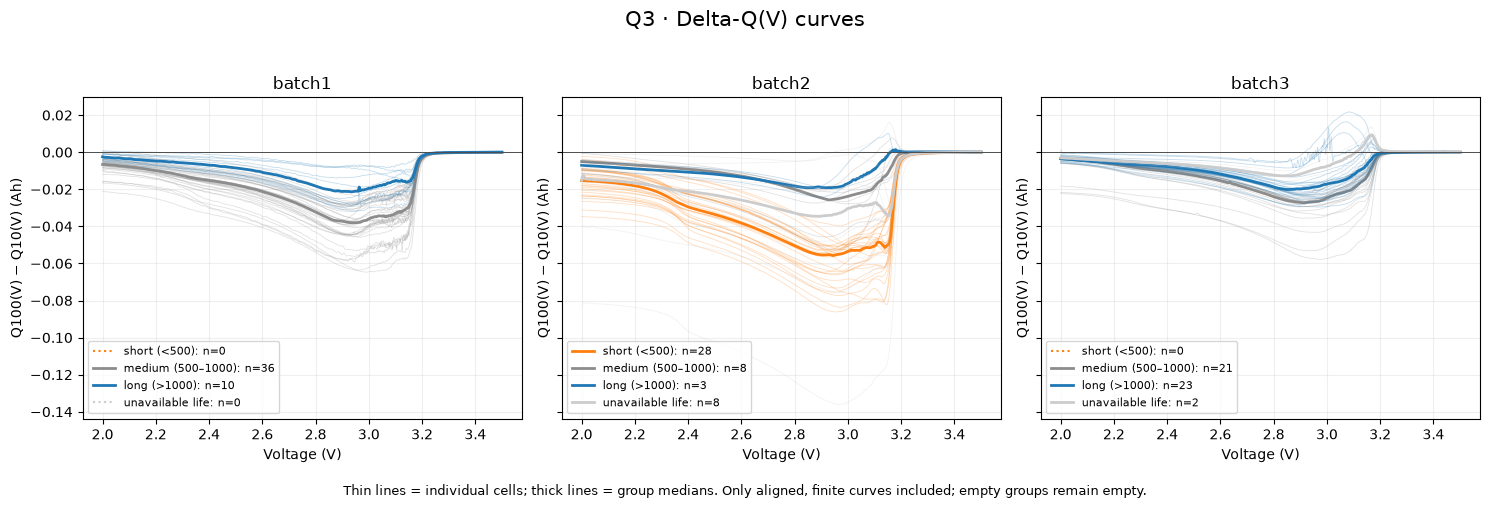

In [5]:
fig = question_gallery.save_gallery_figure(question_gallery.FIGURE_SPECS[3], inputs, OUTPUT_DIR)
plt.show()
plt.close(fig)

## 05. Q3 — Delta-Q variance vs lifetime

ΔQ(V) 분산과 수명 사이의 점 분포를 봅니다. 분산 축은 로그 척도이고 회귀선은 그리지 않습니다.

저장 파일: `05_q3_delta_q_variance.png`

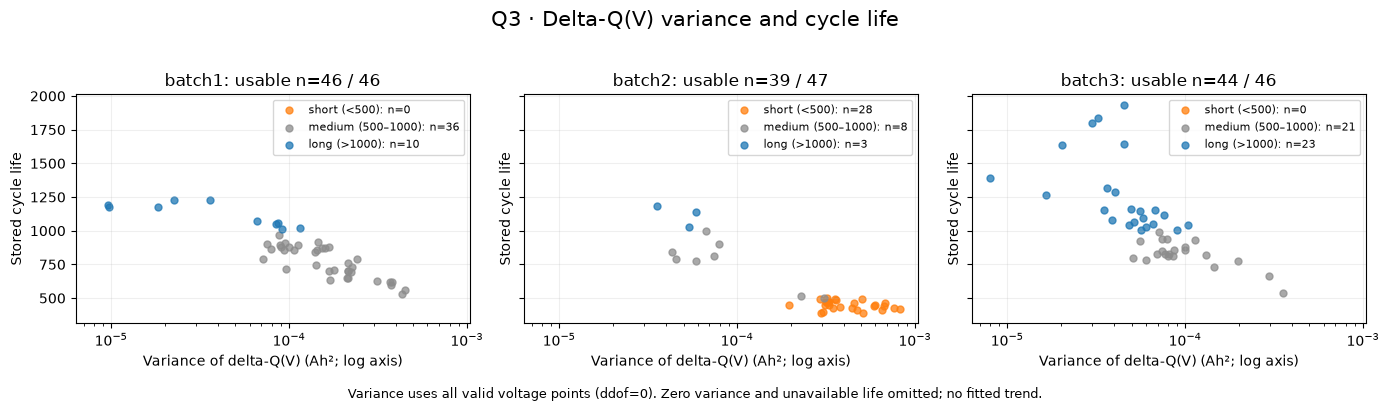

In [6]:
fig = question_gallery.save_gallery_figure(question_gallery.FIGURE_SPECS[4], inputs, OUTPUT_DIR)
plt.show()
plt.close(fig)

## 06. Q4 — Lifetime by charging policy

충전 정책별 개별 수명, 평균과 ±1 표본 표준편차를 봅니다. 정책 순서는 문자열 순이며 성능 순위가 아닙니다. 표준편차는 신뢰구간과 구분합니다.

저장 파일: `06_q4_policy_lifetime.png`

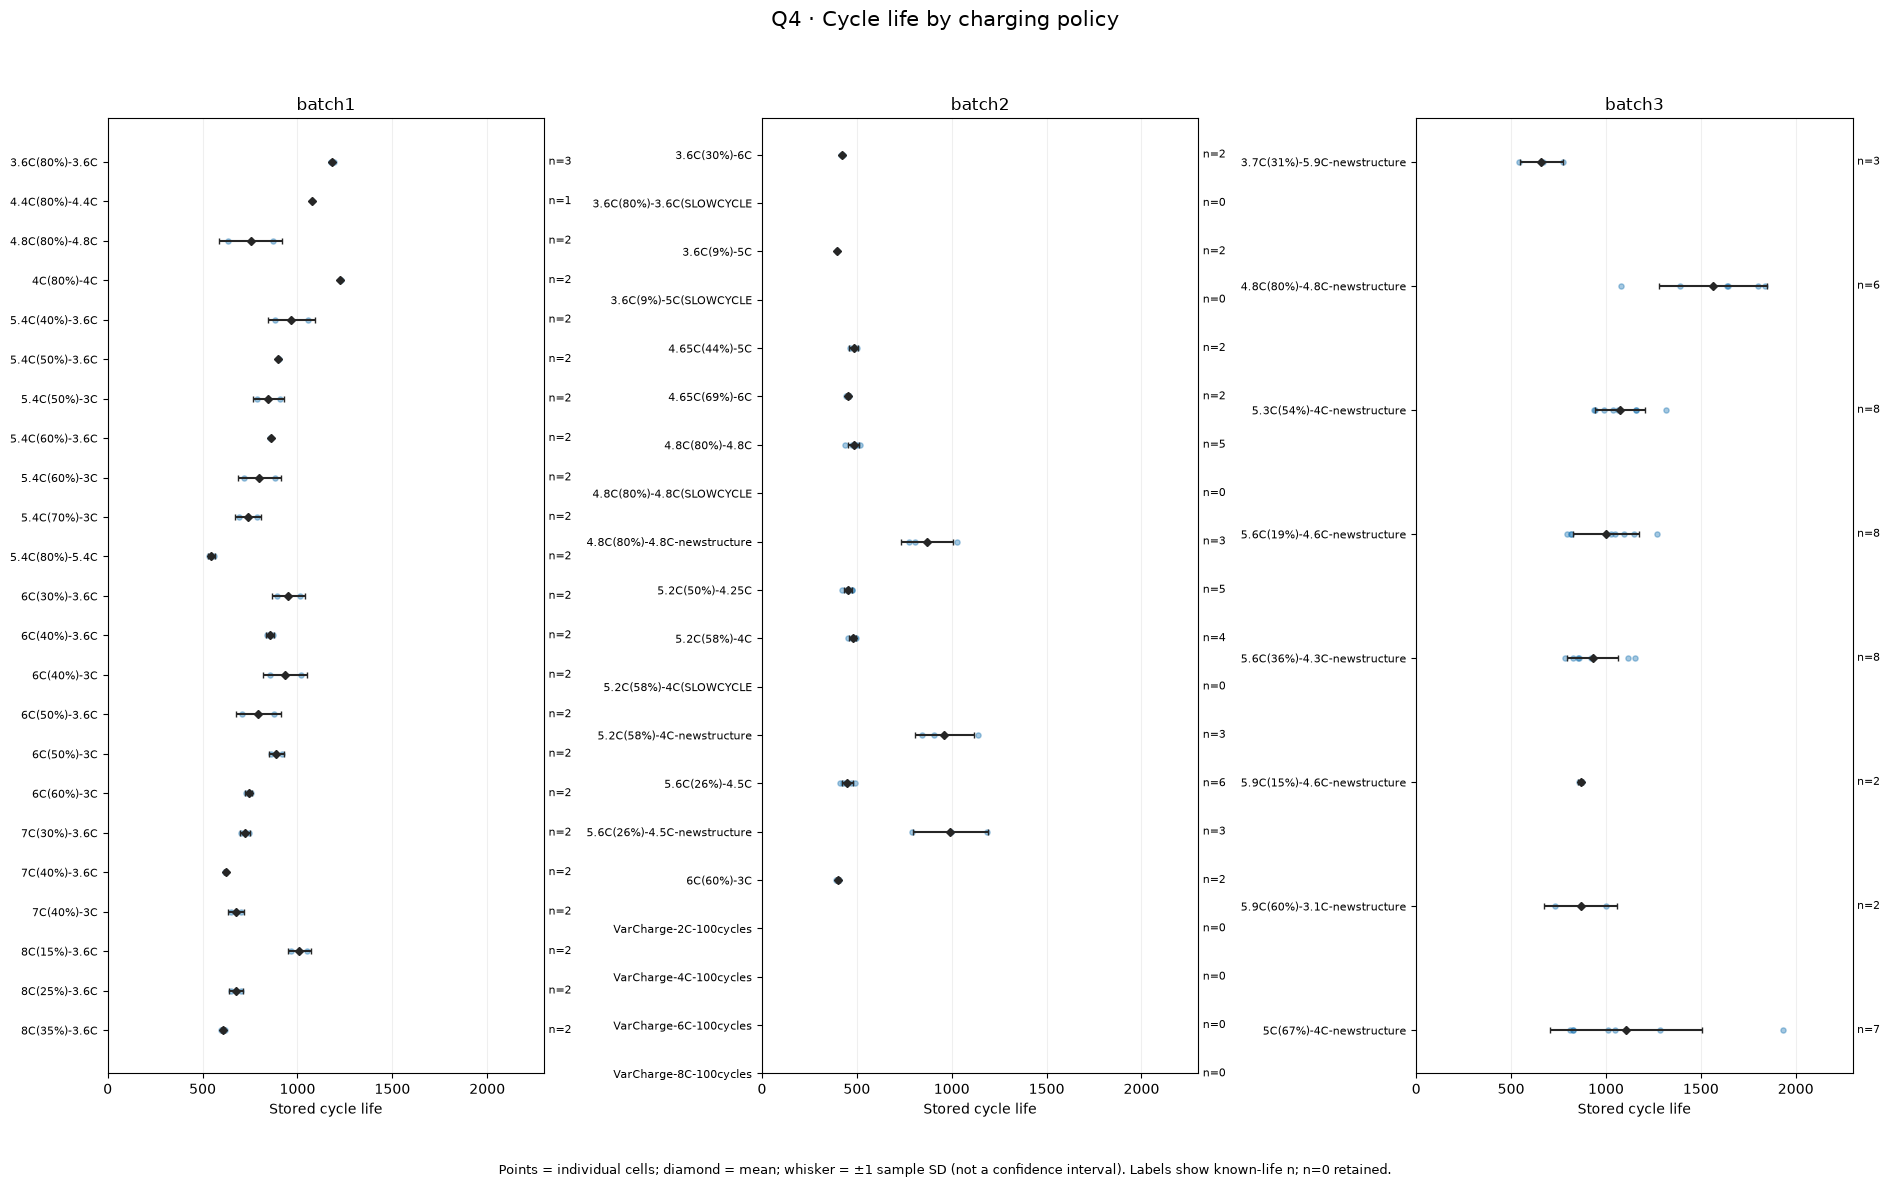

In [7]:
fig = question_gallery.save_gallery_figure(question_gallery.FIGURE_SPECS[5], inputs, OUTPUT_DIR)
plt.show()
plt.close(fig)

## 07. Q4 — Charging measures vs lifetime/early slope

초기 충전 시간 지표와 수명, cycle 10의 양의 전류 최댓값과 초기 QD 기울기를 봅니다. 높은 QD값은 기울기 계산에서도 자동 제외하지 않습니다.

저장 파일: `07_q4_charging_relationships.png`

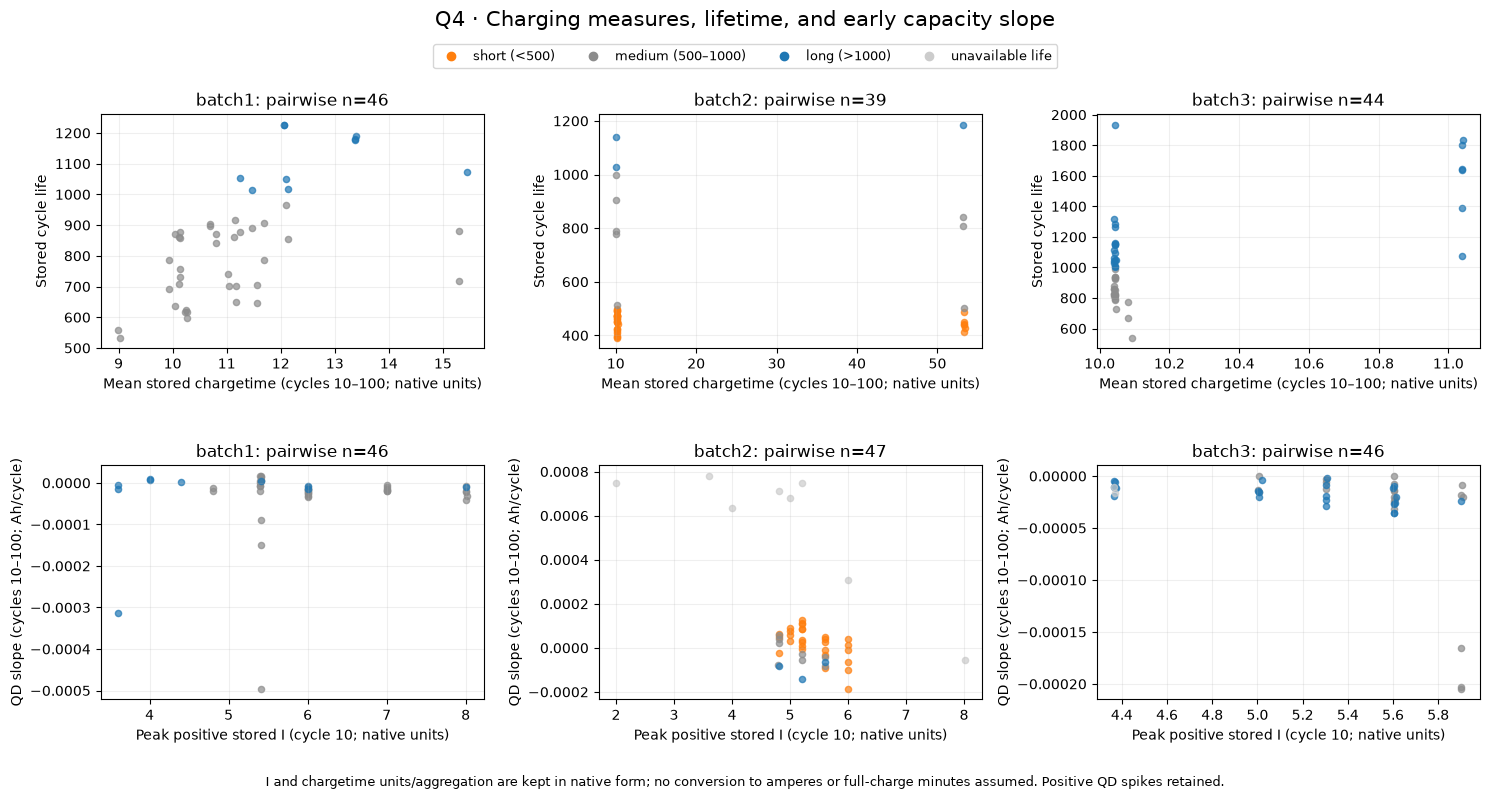

In [8]:
fig = question_gallery.save_gallery_figure(question_gallery.FIGURE_SPECS[6], inputs, OUTPUT_DIR)
plt.show()
plt.close(fig)

## 08. Q5 — Pearson/Spearman correlations with lifetime

초기 Feature와 수명의 Pearson/Spearman 상관계수를 봅니다. Feature 순서는 고정하고, 각 계수의 유효 셀 수를 표시합니다. 강한 Feature 순위를 결정하지 않습니다.

저장 파일: `08_q5_target_correlations.png`

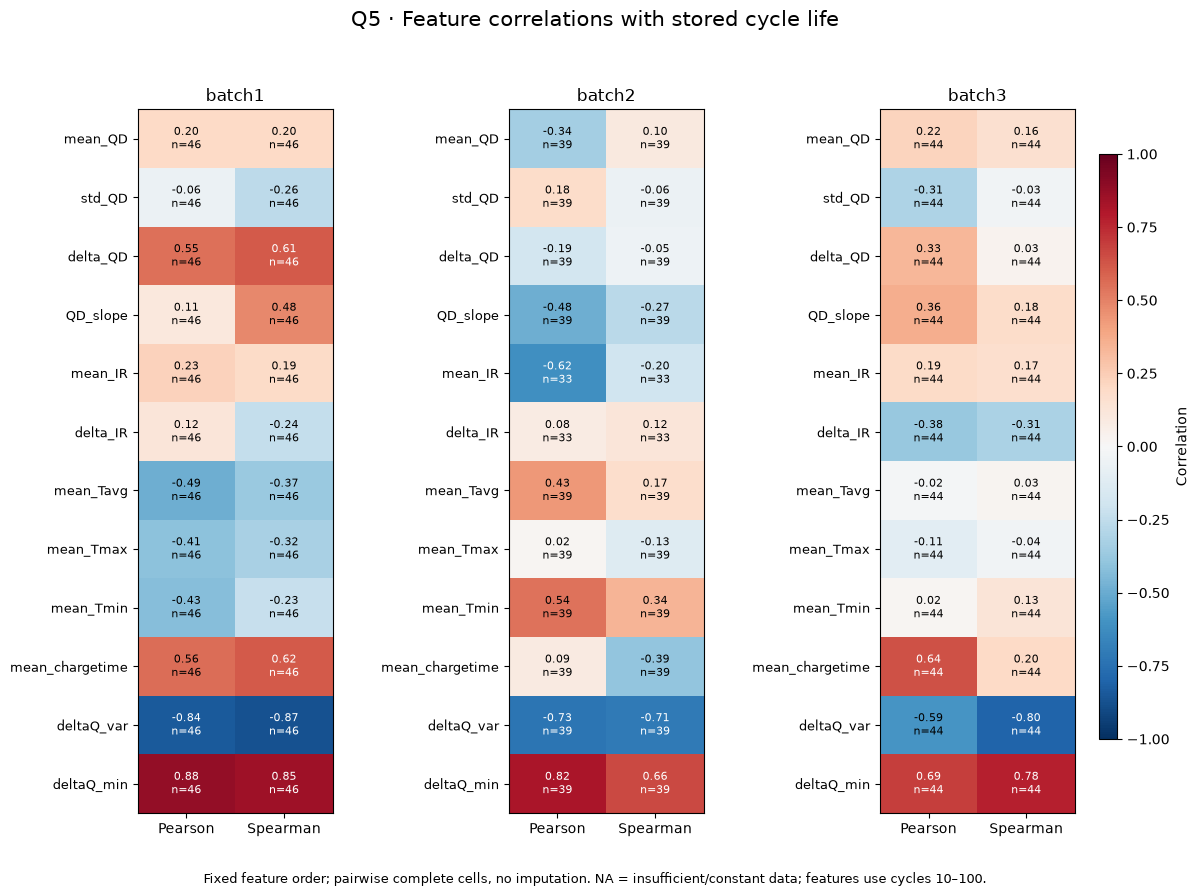

In [9]:
fig = question_gallery.save_gallery_figure(question_gallery.FIGURE_SPECS[7], inputs, OUTPUT_DIR)
plt.show()
plt.close(fig)

## 09. Q5 — Feature correlation matrices

Feature 사이의 Pearson 상관행렬을 봅니다. 수명 누락 셀도 해당 Feature가 있으면 포함합니다. 결측은 채우지 않으며 유효 셀은 변수 쌍마다 달라질 수 있습니다.

저장 파일: `09_q5_feature_correlations.png`

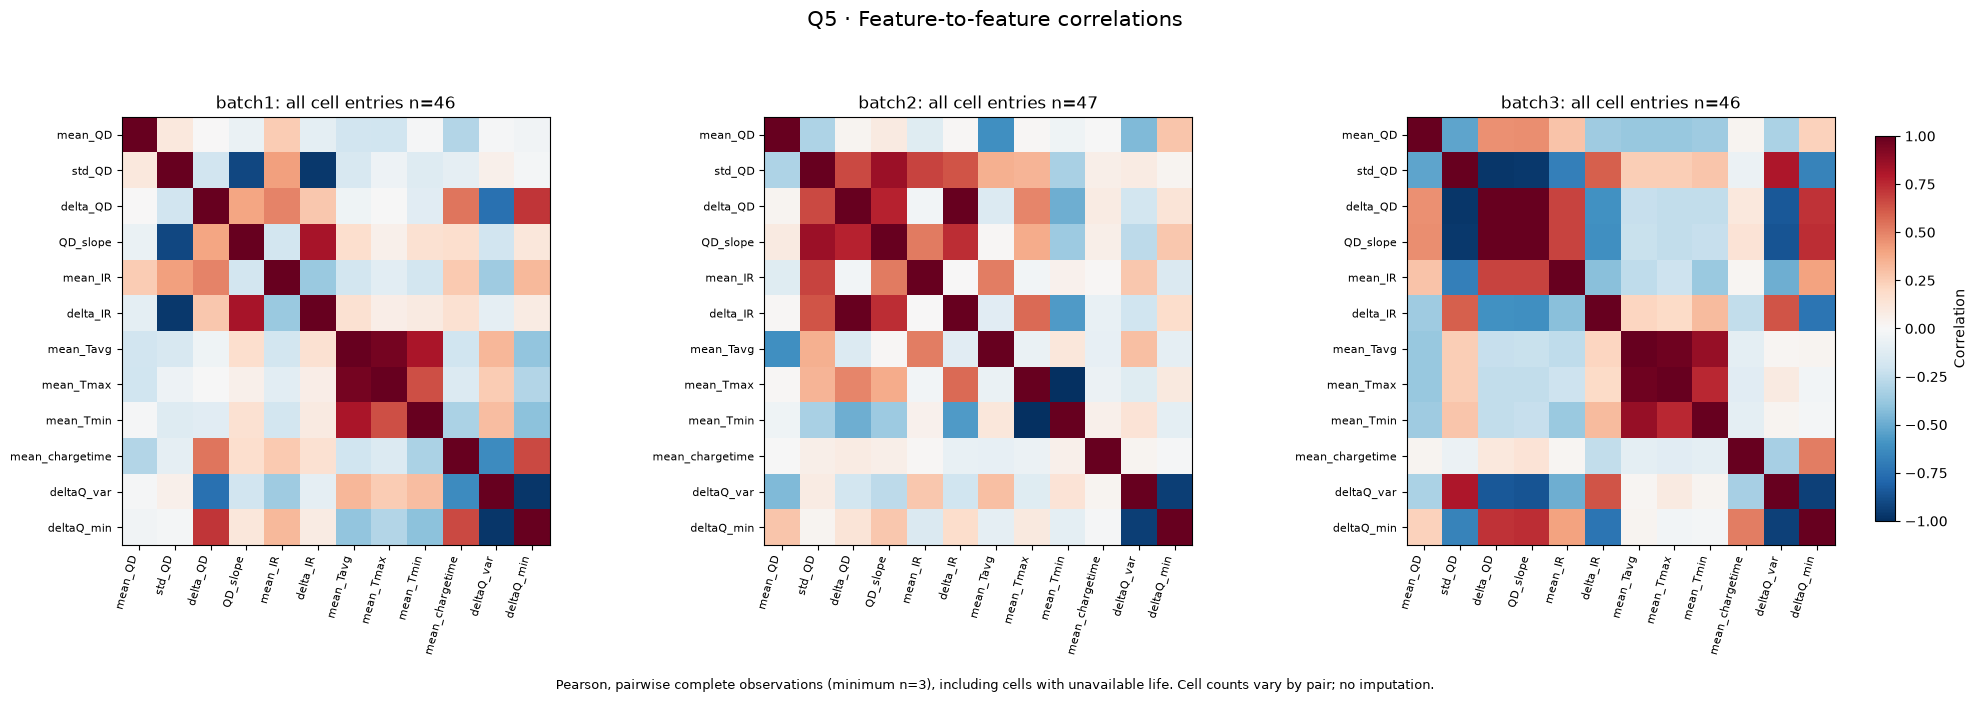

In [10]:
fig = question_gallery.save_gallery_figure(question_gallery.FIGURE_SPECS[8], inputs, OUTPUT_DIR)
plt.show()
plt.close(fig)

원하는 이미지 번호를 기준으로 질문하거나, 별도의 메모에 눈에 띄는 셀·구간·패턴을 기록할 수 있습니다. 이 단계에서는 결과를 먼저 해석하지 않습니다.